Kullanılan cihaz: cpu
X_train: torch.Size([2083, 30, 5]), y_train: torch.Size([2083, 5])
X_val:   torch.Size([423, 30, 5]), y_val:   torch.Size([423, 5])
X_test:  torch.Size([423, 30, 5]), y_test:  torch.Size([423, 5])
Epoch [10/100] -Train Loss: 0.070472 -Val Loss: 0.355224
Epoch [20/100] -Train Loss: 0.021247 -Val Loss: 0.075633
Epoch [30/100] -Train Loss: 0.010340 -Val Loss: 0.037647
Epoch [40/100] -Train Loss: 0.003951 -Val Loss: 0.016673
Epoch [50/100] -Train Loss: 0.002413 -Val Loss: 0.007192
Epoch [60/100] -Train Loss: 0.001744 -Val Loss: 0.009268
Early stopping: Epoch 63'de durduruldu (val loss 15 epoch boyunca iyileşmedi)
En iyi model yüklendi (Best Val Loss: 0.006195)
Final model kaydedildi: lstm_model_final.pt (best_lstm_model.pt ile aynı ağırlıklar)


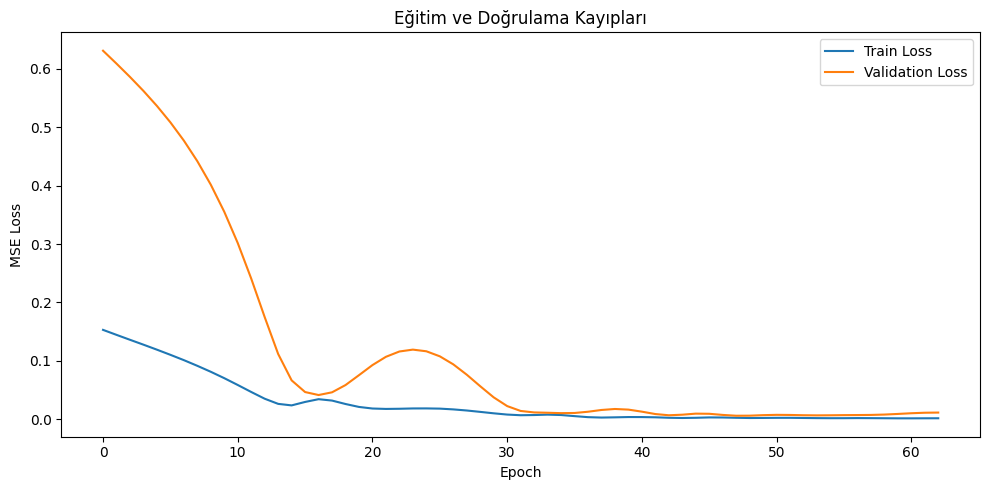

Test Loss (MSE):0.077963

***LSTM modelinde Close Fiyatı için Test Metrikleri***
MAE:  6.8304
RMSE: 10.3057
MAPE: 11.35%

***Bir önceki günde Close Fiyatı için Naive Baseline***
MAE: 0.5038
RMSE:0.7228
MAPE:1.02%

***Karşılaştırma***
Metrik  LSTM        Naive Baseline Sonuç
MAE     6.8304      0.5038         Naive daha iyi
RMSE    10.3057     0.7228         Naive daha iyi
MAPE    11.35       1.02           Naive daha iyi


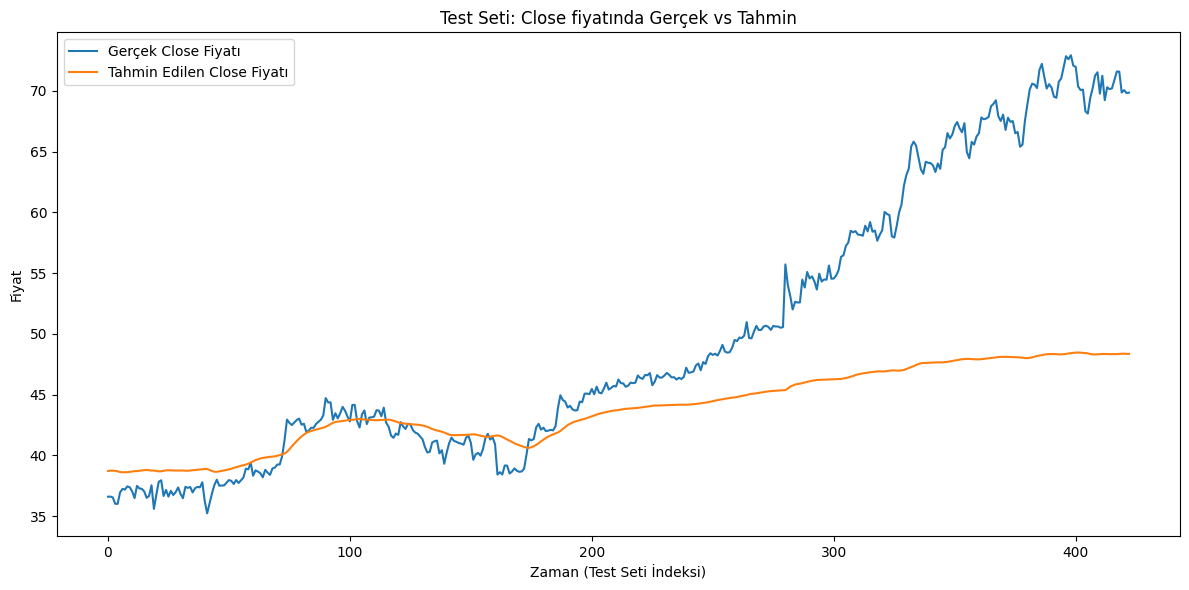


***Bir Sonraki Günün Tahmini***
Open:47.8408
High:45.8160
Low:49.6650
Close:48.3333
Volume:27945030.0000


In [5]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,mean_absolute_error

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan cihaz: {device}")


df=pd.read_csv("dataset.csv")
df["Date"]=pd.to_datetime(df["Date"])
df=df.sort_values("Date").reset_index(drop=True)

feature_cols=["Open","High","Low","Close","Volume"]
data=df[feature_cols].to_numpy()

tensor=torch.tensor(data,dtype=torch.float32)

n = tensor.shape[0]
train_end=int(n*0.7)
val_end=int(n*0.85)

train_data=tensor[:train_end]
val_data=tensor[train_end:val_end]
test_data=tensor[val_end:]

train_min=train_data.min(dim=0,keepdim=True).values
train_max=train_data.max(dim=0,keepdim=True).values

diff=train_max-train_min
diff[diff==0]=1

train_scaled=(train_data-train_min)/diff
val_scaled=(val_data-train_min)/diff
test_scaled=(test_data-train_min)/diff

def create_sequences(data,seq_length):
    xs=[]
    ys=[]
    for i in range(len(data)-seq_length):
        x=data[i:(i+seq_length)]
        y=data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return torch.stack(xs),torch.stack(ys)

seq_length = 30

X_train,y_train=create_sequences(train_scaled,seq_length)
X_val,y_val=create_sequences(val_scaled,seq_length)
X_test,y_test=create_sequences(test_scaled,seq_length)

X_train,y_train=X_train.to(device),y_train.to(device)
X_val,y_val=X_val.to(device),y_val.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self,input_size=5,hidden_size=64,num_layers=2,output_size=5,dropout=0.2):
        super(LSTMModel,self).__init__()
        self.hidden_size=hidden_size
        self.num_layers=num_layers

        self.lstm=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers>1 else 0.0
        )
        self.fc=nn.Linear(hidden_size,output_size)

    def forward(self,x):
        out,(hn,cn)=self.lstm(x)
        last_out=out[:,-1,:]
        out=self.fc(last_out)
        return out

model=LSTMModel(input_size=5,hidden_size=64,num_layers=2,output_size=5).to(device)

criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

num_epochs=100
patience=15
best_val_loss=float('inf')
patience_counter=0

train_losses=[]
val_losses=[]

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    output=model(X_train)
    loss=criterion(output,y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        val_output=model(X_val)
        val_loss=criterion(val_output,y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())


    if val_loss.item()<best_val_loss:
        best_val_loss=val_loss.item()
        patience_counter=0
        torch.save(model.state_dict(),"best_lstm_model.pt")
    else:
        patience_counter+=1
        if patience_counter>=patience:
            print(f"Early stopping: Epoch {epoch+1}'de durduruldu (val loss {patience} epoch boyunca iyileşmedi)")
            break

    if(epoch +1)%10==0:
        print(f"Epoch [{epoch+1}/{num_epochs}] -Train Loss: {loss.item():.6f} -Val Loss: {val_loss.item():.6f}")


model.load_state_dict(torch.load("best_lstm_model.pt",map_location=device))
model.eval()
print(f"En iyi model yüklendi (Best Val Loss: {best_val_loss:.6f})")


torch.save(model.state_dict(),"lstm_model_final.pt")
print("Final model kaydedildi: lstm_model_final.pt (best_lstm_model.pt ile aynı ağırlıklar)")

plt.figure(figsize=(10, 5))
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Eğitim ve Doğrulama Kayıpları")
plt.legend()
plt.tight_layout()
plt.savefig("loss_curve.png")
plt.show()

model.eval()
with torch.no_grad():
    test_output=model(X_test)
    test_loss=criterion(test_output,y_test)

print(f"Test Loss (MSE):{test_loss.item():.6f}")

def inverse_transform(scaled_data,min_vals,max_vals):
    diff=max_vals-min_vals
    return scaled_data*diff+min_vals


test_pred_real =inverse_transform(test_output.cpu(),train_min.cpu(),train_max.cpu())
y_test_real =inverse_transform(y_test.cpu(),train_min.cpu(),train_max.cpu())

close_idx = feature_cols.index("Close")

y_true_close=y_test_real[:,close_idx].detach().numpy()
y_pred_close=test_pred_real[:,close_idx].detach().numpy()

rmse=np.sqrt(mean_squared_error(y_true_close,y_pred_close))
mae=mean_absolute_error(y_true_close,y_pred_close)
mape=np.mean(np.abs((y_true_close-y_pred_close)/y_true_close))*100

print(f"\n***LSTM modelinde Close Fiyatı için Test Metrikleri***")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

naive_pred=y_true_close[:-1]
naive_true=y_true_close[1:]

naive_mae=mean_absolute_error(naive_true,naive_pred)
naive_rmse=np.sqrt(mean_squared_error(naive_true,naive_pred))
naive_mape=np.mean(np.abs((naive_true - naive_pred)/naive_true))*100

print(f"\n***Bir önceki günde Close Fiyatı için Naive Baseline***")
print(f"MAE: {naive_mae:.4f}")
print(f"RMSE:{naive_rmse:.4f}")
print(f"MAPE:{naive_mape:.2f}%")

print(f"\n***Karşılaştırma***")
print(f"{'Metrik':<8}{'LSTM':<12}{'Naive Baseline':<15}{'Sonuç'}")
print(f"{'MAE':<8}{mae:<12.4f}{naive_mae:<15.4f}{'LSTM daha iyi' if mae < naive_mae else 'Naive daha iyi'}")
print(f"{'RMSE':<8}{rmse:<12.4f}{naive_rmse:<15.4f}{'LSTM daha iyi' if rmse < naive_rmse else 'Naive daha iyi'}")
print(f"{'MAPE':<8}{mape:<12.2f}{naive_mape:<15.2f}{'LSTM daha iyi' if mape < naive_mape else 'Naive daha iyi'}")

plt.figure(figsize=(12, 6))
plt.plot(y_true_close,label="Gerçek Close Fiyatı")
plt.plot(y_pred_close,label="Tahmin Edilen Close Fiyatı")
plt.xlabel("Zaman (Test Seti İndeksi)")
plt.ylabel("Fiyat")
plt.title("Test Seti: Close fiyatında Gerçek vs Tahmin")
plt.legend()
plt.tight_layout()
plt.savefig("PredictionVsActual.png")
plt.show()

model.eval()
with torch.no_grad():
    last_sequence=test_scaled[-seq_length:].unsqueeze(0).to(device)
    next_pred_scaled=model(last_sequence)
    next_pred_real=inverse_transform(next_pred_scaled.cpu(),train_min.cpu(),train_max.cpu())

print("\n***Bir Sonraki Günün Tahmini***")
for col,val in zip(feature_cols,next_pred_real.squeeze().tolist()):
    print(f"{col}:{val:.4f}")

